In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [5]:
# Load the dataset
df = pd.read_csv("../data/online_retail_II.csv", encoding="ISO-8859-1")

print("Dataset loaded successfully ✅")

Dataset loaded successfully ✅


In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [7]:
df.shape

(541910, 8)

In [8]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  str    
 1   StockCode    541910 non-null  str    
 2   Description  540456 non-null  str    
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  str    
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [10]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [12]:
(df.isnull().sum()/len(df))*100

Invoice         0.000000
StockCode       0.000000
Description     0.268310
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    24.926648
Country         0.000000
dtype: float64

In [13]:
df_clean=df.copy()
print("backup created successfully")

backup created successfully


In [16]:
df_clean=df_clean.dropna(subset=['Description'])

In [17]:
duplicates=df_clean.duplicated().sum()

print(f"number of duplicate rows in the dataset: {duplicates}")

number of duplicate rows in the dataset: 5268


In [18]:
df_clean=df_clean.drop_duplicates()

print("new shape",df.shape)

new shape (541910, 8)


In [ ]:
#check for neagtive values

negative_quantity=(df_clean['Quantity']<0).sum()

#check neagtive price

negative_price=(df_clean['Price']<0).sum()

cancelled_orders=df_clean['Invoice'].str.startswith("C").sum()

print("negative quantity ", negative_quantity)
print("negative price:", negative_price)
print("cancelled orders:", cancelled_orders)

negative quantity  9725
negative price: 2
cancelled orders: 9251


In [ ]:
# Create dataset containing only completed sales
df_sales = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0) &
    (~df_clean["Invoice"].str.startswith("C"))
].copy()

print("Sales Dataset Shape:", df_sales.shape)

Sales Dataset Shape: (524879, 8)


In [29]:
# Convert InvoiceDate to datetime
df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"])

print(df_sales["InvoiceDate"].dtype)

datetime64[us]


In [32]:
df_sales['revenue']=df_sales['Quantity']*df_sales['Price']
df_sales.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [34]:
df_sales['Year']=df_sales['InvoiceDate'].dt.year
df_sales['month']=df_sales['InvoiceDate'].dt.month
df_sales['Month_Name']=df_sales['InvoiceDate'].dt.month_name()
df_sales['Day']=df_sales['InvoiceDate'].dt.day
df_sales['quarter']=df_sales['InvoiceDate'].dt.quarter


In [36]:
# ==============================
# Business KPIs
# ==============================

total_revenue = df_sales["revenue"].sum()
total_orders = df_sales["Invoice"].nunique()
total_products_sold = df_sales["Quantity"].sum()
total_customers = df_sales["Customer ID"].nunique()
total_countries = df_sales["Country"].nunique()

print(f"💰 Total Revenue: ${total_revenue:,.2f}")
print(f"📦 Total Orders: {total_orders:,}")
print(f"🛒 Total Products Sold: {total_products_sold:,}")
print(f"👥 Total Customers: {total_customers:,}")
print(f"🌍 Countries Served: {total_countries}")

💰 Total Revenue: $10,642,128.80
📦 Total Orders: 19,960
🛒 Total Products Sold: 5,572,421
👥 Total Customers: 4,338
🌍 Countries Served: 38


In [37]:
average_order_value = total_revenue / total_orders

print(f"🛍️ Average Order Value (AOV): ${average_order_value:.2f}")

🛍️ Average Order Value (AOV): $533.17


In [43]:
df_sales.columns


Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'revenue', 'Year', 'month',
       'Month_Name', 'Day', 'quarter'],
      dtype='str')

In [44]:
df_sales.rename(columns={
    "revenue": "Revenue",
    "month": "Month",
    "quarter": "Quarter"
}, inplace=True)

df_sales.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month',
       'Month_Name', 'Day', 'Quarter'],
      dtype='str')

In [45]:
monthly_revenue = (
    df_sales.groupby(["Year", "Month", "Month_Name"])["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,Year,Month,Month_Name,Revenue
0,2010,12,December,821452.730
1,2011,1,January,689811.610
2,2011,2,February,522545.560
3,2011,3,March,716215.260
4,2011,4,April,536968.491


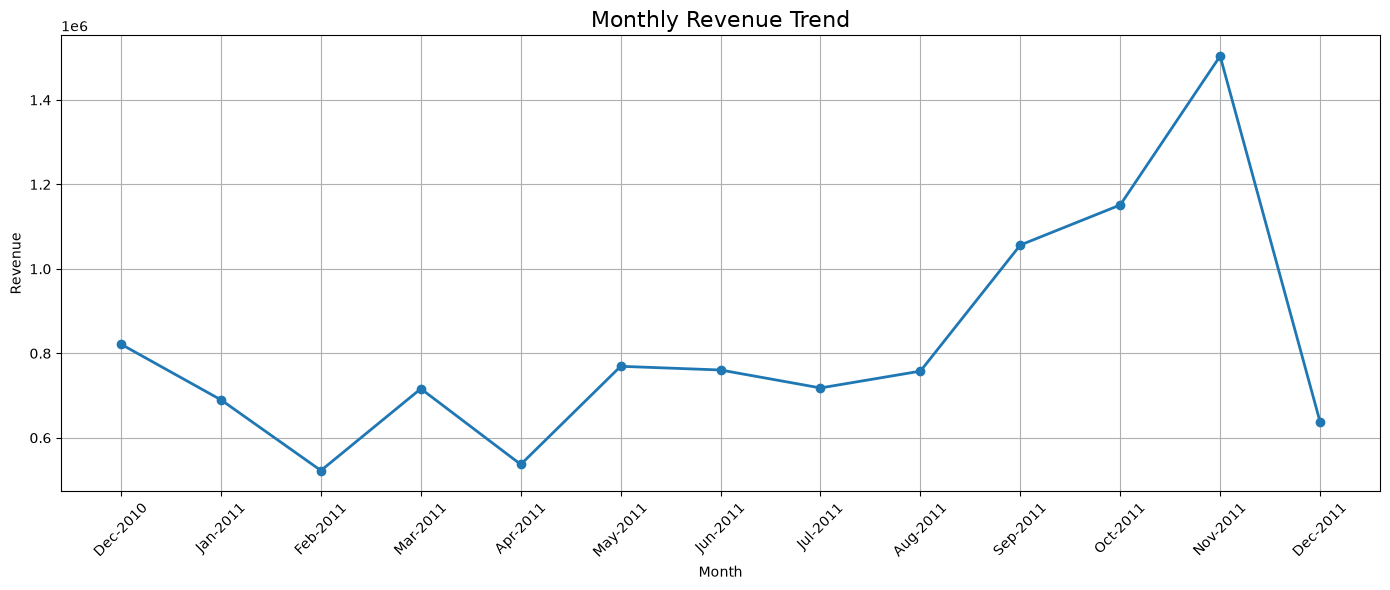

In [46]:
import matplotlib.pyplot as plt

monthly_revenue = (
    df_sales.groupby(["Year", "Month", "Month_Name"])["Revenue"]
    .sum()
    .reset_index()
)

# Create labels like Dec-2010, Jan-2011
monthly_revenue["Label"] = (
    monthly_revenue["Month_Name"].str[:3]
    + "-"
    + monthly_revenue["Year"].astype(str)
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue["Label"],
    monthly_revenue["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

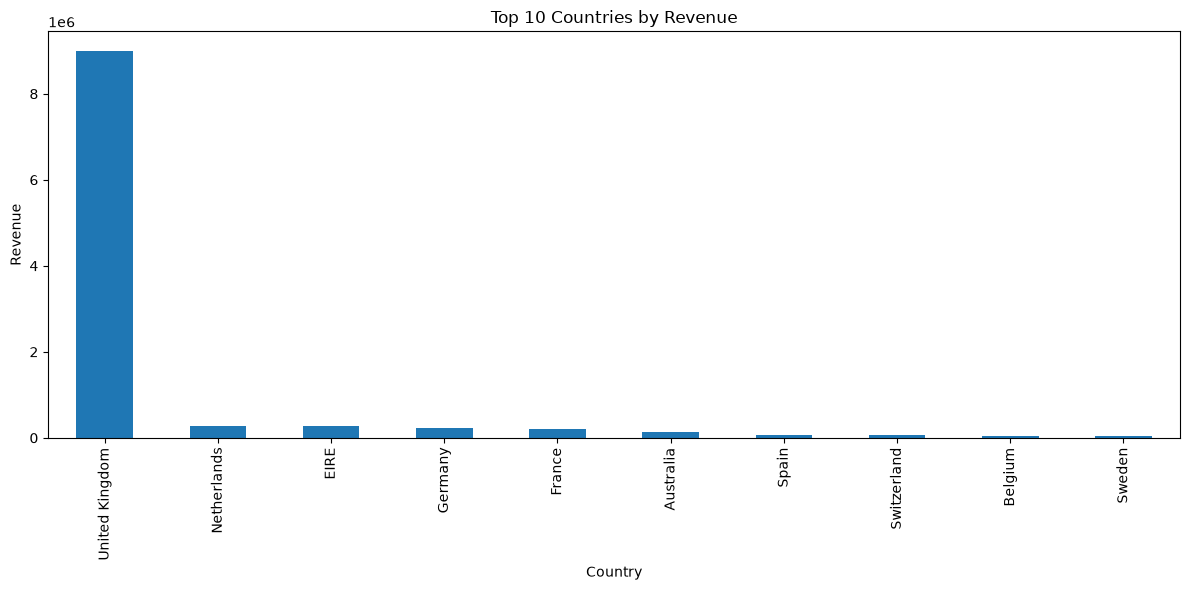

In [47]:
top_countries = (
    df_sales.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

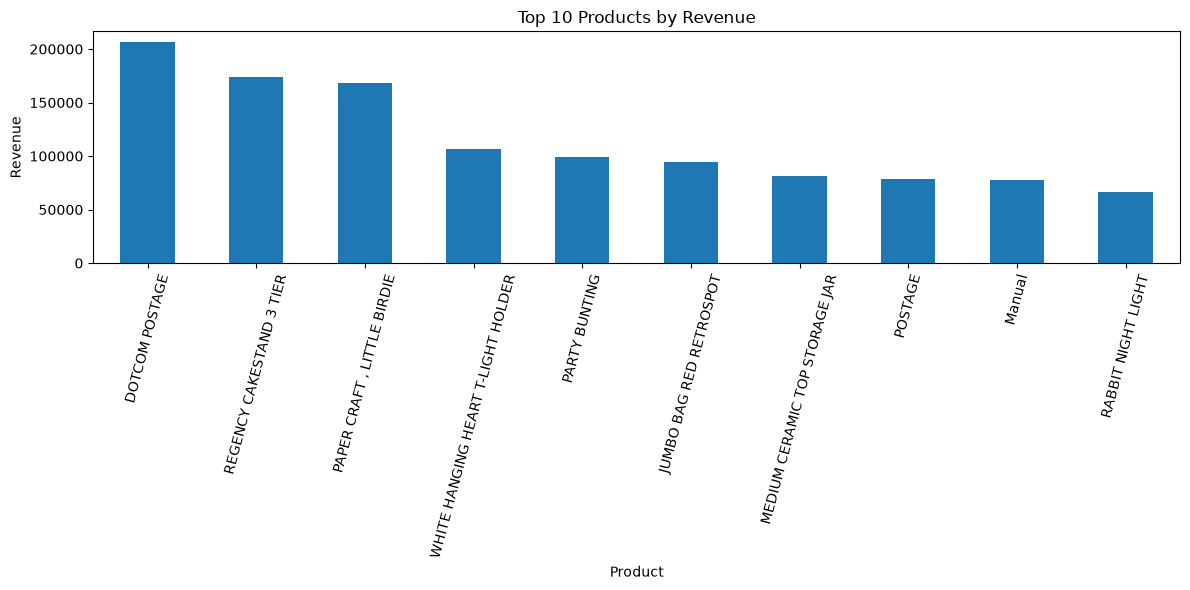

In [48]:
top_products = (
    df_sales.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [54]:
df_customer = df_sales.dropna(subset=["Customer ID"]).copy()

print(df_customer.shape)

(392693, 14)


In [56]:
snapshot_date=df_customer['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [59]:
df_customer.groupby("Customer ID")
df_customer.groupby("Customer ID").size()

Customer ID
12346.0      1
12347.0    182
12348.0     31
12349.0     73
12350.0     17
          ... 
18280.0     10
18281.0      7
18282.0     12
18283.0    721
18287.0     70
Length: 4338, dtype: int64

In [60]:
recency = df_customer.groupby("Customer ID")["InvoiceDate"].max()

recency.head()

Customer ID
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
12350.0   2011-02-02 16:01:00
Name: InvoiceDate, dtype: datetime64[us]

In [61]:
last_purchase = df_customer.groupby("Customer ID")["InvoiceDate"].max()

last_purchase.head()

Customer ID
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
12350.0   2011-02-02 16:01:00
Name: InvoiceDate, dtype: datetime64[us]

In [62]:
rfm = df_customer.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [63]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [64]:
monthly_sales = (
    df_sales.groupby(["Year","Month"])["Revenue"]
    .sum()
    .reset_index()
)

country_sales = (
    df_sales.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

product_sales = (
    df_sales.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers = (
    rfm.sort_values("Monetary", ascending=False)
    .head(10)
)

In [66]:
monthly_sales.to_csv("../dashboard/monthly_sales.csv", index=False)

country_sales.to_csv("../dashboard/country_sales.csv")

product_sales.to_csv("../dashboard/product_sales.csv")

top_customers.to_csv("../dashboard/top_customers.csv")

In [68]:
import sqlite3
import pandas as pd

# Create database connection
conn = sqlite3.connect("retailpulse.db")

print("Database connected")

Database connected


In [70]:
monthly_sales.head()

,Year,Month,Revenue
0,2010,12,821452.730
1,2011,1,689811.610
2,2011,2,522545.560
3,2011,3,716215.260
4,2011,4,536968.491


In [71]:
monthly_sales.to_sql(
    "monthly_sales",
    conn,
    if_exists="replace",
    index=False
)

country_sales.to_sql(
    "country_sales",
    conn,
    if_exists="replace",
    index=False
)

product_sales.to_sql(
    "product_sales",
    conn,
    if_exists="replace",
    index=False
)

top_customers.to_sql(
    "top_customers",
    conn,
    if_exists="replace",
    index=False
)

print("All tables created")

All tables created


In [72]:
pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,monthly_sales
1,country_sales
2,product_sales
3,top_customers


In [73]:
query = """
SELECT *
FROM monthly_sales
ORDER BY revenue DESC;
"""

result = pd.read_sql(query, conn)

result.head()

,Year,Month,Revenue
0,2011,11,1503866.780
1,2011,10,1151263.730
2,2011,9,1056435.192
3,2010,12,821452.730
4,2011,5,769296.610


In [74]:
monthly_sales.to_sql(
    "monthly_sales",
    conn,
    if_exists="replace",
    index=False
)

print("monthly_sales table created")

monthly_sales table created


In [75]:
pd.read_sql(
    "SELECT * FROM monthly_sales LIMIT 5;",
    conn
)

,Year,Month,Revenue
0,2010,12,821452.730
1,2011,1,689811.610
2,2011,2,522545.560
3,2011,3,716215.260
4,2011,4,536968.491


In [76]:
#highest  revenue month
query = """
SELECT 
    Year,
    Month,
    Revenue
FROM monthly_sales
ORDER BY Revenue DESC
LIMIT 10;
"""

top_months = pd.read_sql(query, conn)

top_months

,Year,Month,Revenue
0,2011,11,1503866.780
1,2011,10,1151263.730
2,2011,9,1056435.192
3,2010,12,821452.730
4,2011,5,769296.610
5,2011,6,760547.010
6,2011,8,757841.380
7,2011,7,718076.121
8,2011,3,716215.260
9,2011,1,689811.610


In [77]:
top_customers.to_sql(
    "top_customers",
    conn,
    if_exists="replace",
    index=False
)

print("top_customers table created")

top_customers table created


In [79]:
top_customers.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
14646.0,2,73,280206.02,4,4,4,444
18102.0,1,60,259657.30,4,4,4,444
17450.0,8,46,194390.79,4,4,4,444
16446.0,1,2,168472.50,4,2,4,424
14911.0,1,201,143711.17,4,4,4,444


In [80]:
top_customers_sql = top_customers.reset_index()

top_customers_sql.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,14646.0,2,73,280206.02,4,4,4,444
1,18102.0,1,60,259657.30,4,4,4,444
2,17450.0,8,46,194390.79,4,4,4,444
3,16446.0,1,2,168472.50,4,2,4,424
4,14911.0,1,201,143711.17,4,4,4,444


In [81]:
top_customers_sql.to_sql(
    "top_customers",
    conn,
    if_exists="replace",
    index=False
)

print("RFM table loaded")

RFM table loaded


In [84]:
top_customers_sql = top_customers.reset_index()

top_customers_sql.to_sql(
    "top_customers",
    conn,
    if_exists="replace",
    index=False
)

print("RFM table updated")

RFM table updated


In [85]:
pd.read_sql(
    "PRAGMA table_info(top_customers);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,Customer ID,REAL,0,None,0
1,1,Recency,INTEGER,0,None,0
2,2,Frequency,INTEGER,0,None,0
3,3,Monetary,REAL,0,None,0
4,4,R_Score,TEXT,0,None,0
5,5,F_Score,TEXT,0,None,0
6,6,M_Score,TEXT,0,None,0
7,7,RFM_Score,TEXT,0,None,0


In [86]:
query = """
SELECT
    "Customer ID",
    Monetary,
    Frequency,
    RFM_Score,
    RANK() OVER(
        ORDER BY Monetary DESC
    ) AS customer_rank
FROM top_customers;
"""

customer_rank = pd.read_sql(query, conn)

customer_rank.head(10)

,Customer ID,Monetary,Frequency,RFM_Score,customer_rank
0,14646.0,280206.02,73,444,1
1,18102.0,259657.30,60,444,2
2,17450.0,194390.79,46,444,3
3,16446.0,168472.50,2,424,4
4,14911.0,143711.17,201,444,5
5,12415.0,124914.53,21,344,6
6,14156.0,117210.08,55,444,7
7,17511.0,91062.38,31,444,8
8,16029.0,80850.84,63,344,9
9,12346.0,77183.60,1,114,10


In [87]:
country_sales.to_sql(
    "country_sales",
    conn,
    if_exists="replace",
    index=False
)

print("country_sales table created")

country_sales table created


In [90]:
country_sales.head()

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209643.370
Name: Revenue, dtype: float64

In [91]:
country_sales_sql = country_sales.reset_index()

country_sales_sql.head()

,Country,Revenue
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209643.370


In [93]:
country_sales_sql.to_sql(
    "country_sales",
    conn,
    if_exists="replace",
    index=False
)

print("country table updated")

country table updated


In [94]:
query = """
SELECT
    Country,
    Revenue
FROM country_sales
ORDER BY Revenue DESC
LIMIT 10;
"""

country_analysis = pd.read_sql(query, conn)

country_analysis

,Country,Revenue
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209643.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


In [95]:
import os

os.getcwd()

'c:\\Users\\Rajkumar\\OneDrive\\ドキュメント\\RetailPulse\\notebooks'

In [96]:
import os

os.listdir()

['01_data_cleaning.ipynb', 'retailpulse.db']

In [97]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

..\.venv\Lib\site-packages\matplotlib\mpl-data\sample_data\data_x_x2_x3.csv
..\.venv\Lib\site-packages\matplotlib\mpl-data\sample_data\msft.csv
..\.venv\Lib\site-packages\matplotlib\mpl-data\sample_data\Stocks.csv
..\.venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-1.csv
..\.venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-2.csv
..\.venv\Lib\site-packages\numpy\random\tests\data\pcg64-testset-1.csv
..\.venv\Lib\site-packages\numpy\random\tests\data\pcg64-testset-2.csv
..\.venv\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-1.csv
..\.venv\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-2.csv
..\.venv\Lib\site-packages\numpy\random\tests\data\philox-testset-1.csv
..\.venv\Lib\site-packages\numpy\random\tests\data\philox-testset-2.csv
..\.venv\Lib\site-packages\numpy\random\tests\data\sfc64-testset-1.csv
..\.venv\Lib\site-packages\numpy\random\tests\data\sfc64-testset-2.csv
..\.venv\Lib\site-packages\numpy\_core\tests\data\umath-valida

In [98]:
import os

print(os.path.abspath("../dashboard"))

c:\Users\Rajkumar\OneDrive\ドキュメント\RetailPulse\dashboard


In [1]:
import os

print(os.listdir("../dashboard"))

['country_sales.csv', 'monthly_sales.csv', 'product_sales.csv', 'top_customers.csv']
